## **ENDUTIH 2022.**

### **MATERIA: ESTADÍSTICA.**

Profesora: Claudia García Blanquel.

Alumno:
- Hernández Martínez Pablo.
- Reyes Calva Angel David.

Grupo: 4AM1.

## **PRUEBAS DE HIPÓTESIS.**

### **1. Importación de librerias.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, chi2, ttest_ind, shapiro, levene, norm, t as t_dist
from statsmodels.stats.proportion import proportions_ztest

sns.set_style("whitegrid")

### **2. Carga de los csv.**

In [2]:
# Cargar las tres submuestras
muestras = {}
for i in range(1, 4):
    archivo = f"submuestra{i}.csv"
    df = pd.read_csv(archivo)
    muestras[f"submuestra{i}"] = df

# Crear df_total (combinado con indicador de submuestra)
df_total = pd.concat(
    [df.assign(subconjunto=f"Submuestra {i}") for i, (_, df) in enumerate(muestras.items(), start=1)],
    ignore_index=True
)

# Crear variable 'edad_grupo' (necesaria para chi-cuadrado)
bins = [0, 18, 30, 40, 50, 60, 110]
labels = ['<18', '18-29', '30-39', '40-49', '50-59', '60+']
for key in muestras:
    muestras[key]['edad_grupo'] = pd.cut(muestras[key]['EDAD'], bins=bins, labels=labels, right=False)
df_total['edad_grupo'] = pd.cut(df_total['EDAD'], bins=bins, labels=labels, right=False)

# Filtrar por sexo (para la prueba de proporciones)
df_hombres = df_total[df_total['SEXO'] == 1]
df_mujeres = df_total[df_total['SEXO'] == 2]

# Función V de Cramér (usada en la prueba chi-cuadrado)
def cramer_v(tabla):
    chi2, _, _, _ = chi2_contingency(tabla)
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt(chi2 / (n * min(k-1, r-1)))

### **H1: Prueba de independencia Chi‑cuadrado (edad_grupo vs P8_4_2)**

### **Pregunta de investigación:**
### **¿Existe relación entre la edad y el tipo de celular que usan los mexicanos?**

#### Hipótesis
- H₀: La edad agrupada y el tipo de celular (smartphone/básico) son independientes en la población mexicana.
-  H₁: Existe una asociación entre la edad agrupada y el tipo de celular.
- Nivel de significancia: α = 0.005


PRUEBA CHI-CUADRADO DE INDEPENDENCIA
------------------------------------------------------------
Variables analizadas:
• Edad agrupada
• Tipo de celular utilizado
------------------------------------------------------------
Estadístico χ² calculado      : 32.182
Valor crítico χ² (α=0.005)  : 16.750
Grados de libertad            : 5
p-valor                       : 0.000005
V de Cramér                   : 0.328

Interpretación:
Se rechaza la hipótesis nula (H₀).
Existe evidencia estadísticamente significativa para afirmar que la edad agrupada y el tipo de celular utilizado están asociadas.

Magnitud de la asociación (V de Cramér): 0.328
La asociación observada es moderada.


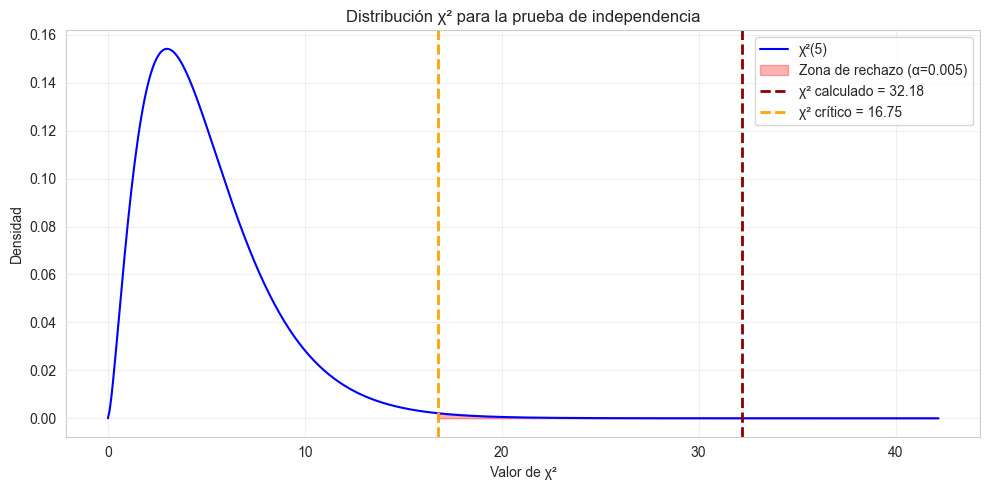


COMPARACIÓN DE PROPORCIONES
------------------------------------------------------------
Uso de smartphone: menores de 18 años vs adultos de 60 años o más
------------------------------------------------------------
Proporción de usuarios (<18 años) : 0.980
Proporción de usuarios (60+ años) : 0.696
Diferencia de proporciones        : 0.284
IC del 95%                        : [0.145, 0.423]

Interpretación:
El intervalo de confianza no contiene el valor 0, por lo que existe evidencia de una diferencia estadísticamente significativa entre ambos grupos.


In [3]:
# Construyo la tabla de contingencia entre grupo de edad y tipo de celular
tabla = pd.crosstab(df_total['edad_grupo'], df_total['P8_4_2'])

# Aplico la prueba Chi-cuadrado de independencia
chi2_calc, p_val, dof, esperados = chi2_contingency(tabla)

# Calculo el tamaño del efecto mediante V de Cramér
v = cramer_v(tabla)

alpha = 0.005

# Obtengo el valor crítico de Chi-cuadrado para el nivel de significancia definido
chi2_teo = chi2.ppf(1 - alpha, dof)

print("\nPRUEBA CHI-CUADRADO DE INDEPENDENCIA")
print("-" * 60)
print("Variables analizadas:")
print("• Edad agrupada")
print("• Tipo de celular utilizado")
print("-" * 60)

print(f"Estadístico χ² calculado      : {chi2_calc:.3f}")
print(f"Valor crítico χ² (α={alpha})  : {chi2_teo:.3f}")
print(f"Grados de libertad            : {dof}")
print(f"p-valor                       : {p_val:.6f}")
print(f"V de Cramér                   : {v:.3f}")

print("\nInterpretación:")

if p_val < alpha:
    print("Se rechaza la hipótesis nula (H₀).")
    print(
        "Existe evidencia estadísticamente significativa para afirmar que "
        "la edad agrupada y el tipo de celular utilizado están asociadas."
    )
else:
    print("No se rechaza la hipótesis nula (H₀).")
    print(
        "No existe evidencia suficiente para afirmar que la edad agrupada "
        "y el tipo de celular utilizado están asociadas."
    )

print(f"\nMagnitud de la asociación (V de Cramér): {v:.3f}")

if v < 0.10:
    print("La asociación observada es muy débil.")
elif v < 0.30:
    print("La asociación observada es débil.")
elif v < 0.50:
    print("La asociación observada es moderada.")
else:
    print("La asociación observada es fuerte.")

# Genero valores para representar la distribución χ²
x = np.linspace(0, chi2_calc + 10, 500)
y = chi2.pdf(x, dof)

plt.figure(figsize=(10, 5))

# Grafico la curva de densidad de la distribución χ²
plt.plot(x, y, 'b-', label=f'χ²({dof})')

# Resalto la región correspondiente a la zona de rechazo
x_rech = np.linspace(chi2_teo, max(x), 200)
plt.fill_between(
    x_rech,
    chi2.pdf(x_rech, dof),
    color='red',
    alpha=0.3,
    label=f'Zona de rechazo (α={alpha})'
)

# Marco el estadístico calculado obtenido en la muestra
plt.axvline(
    chi2_calc,
    color='darkred',
    linestyle='--',
    linewidth=2,
    label=f'χ² calculado = {chi2_calc:.2f}'
)

# Marco el valor crítico teórico
plt.axvline(
    chi2_teo,
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f'χ² crítico = {chi2_teo:.2f}'
)

plt.title('Distribución χ² para la prueba de independencia')
plt.xlabel('Valor de χ²')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Guardo la proporción de menores de 18 años que utilizan smartphone
prop_joven = (
    df_total[df_total['edad_grupo'] == '<18']['P8_4_2']
    .value_counts(normalize=True)
    .get(1, 0)
)

# Guardo la proporción de personas de 60 años o más que utilizan smartphone
prop_mayor = (
    df_total[df_total['edad_grupo'] == '60+']['P8_4_2']
    .value_counts(normalize=True)
    .get(1, 0)
)

# Obtengo el tamaño de muestra de ambos grupos
n_joven = len(df_total[df_total['edad_grupo'] == '<18'])
n_mayor = len(df_total[df_total['edad_grupo'] == '60+'])

# Calculo la diferencia entre las proporciones observadas
dif = prop_joven - prop_mayor

# Estimo el error estándar de la diferencia de proporciones
se = np.sqrt(
    prop_joven * (1 - prop_joven) / n_joven +
    prop_mayor * (1 - prop_mayor) / n_mayor
)

# Obtengo el valor crítico para un intervalo de confianza del 95%
z_crit = norm.ppf(0.975)

# Calculo los límites del intervalo de confianza
ic_inf = dif - z_crit * se
ic_sup = dif + z_crit * se

print("\nCOMPARACIÓN DE PROPORCIONES")
print("-" * 60)
print("Uso de smartphone: menores de 18 años vs adultos de 60 años o más")
print("-" * 60)

print(f"Proporción de usuarios (<18 años) : {prop_joven:.3f}")
print(f"Proporción de usuarios (60+ años) : {prop_mayor:.3f}")
print(f"Diferencia de proporciones        : {dif:.3f}")
print(f"IC del 95%                        : [{ic_inf:.3f}, {ic_sup:.3f}]")

print("\nInterpretación:")

if ic_inf > 0 or ic_sup < 0:
    print(
        "El intervalo de confianza no contiene el valor 0, por lo que existe evidencia "
        "de una diferencia estadísticamente significativa entre ambos grupos."
    )
else:
    print(
        "El intervalo de confianza contiene el valor 0, por lo que no existe evidencia "
        "suficiente para afirmar una diferencia estadísticamente significativa entre ambos grupos."
    )

### **H2: Prueba de diferencia de proporciones de Smartphone (hombres vs mujeres)**

### **Pregunta de investigación complementaria:**
### **¿Existe diferencia en la probabilidad de tener un smartphone según el sexo?**

#### Hipótesis
- H₀: La proporción de usuarios de smartphone es igual en hombres y mujeres (p_h = p_m).
- H₁: Las proporciones son diferentes (p_h ≠ p_m).
- Nivel de significancia: α = 0.05


PRUEBA Z PARA DIFERENCIA DE PROPORCIONES
------------------------------------------------------------
Variables analizadas:
• Sexo (hombre / mujer)
• Tipo de celular (Smartphone)
------------------------------------------------------------
Proporción hombres      : 0.885
Proporción mujeres      : 0.882
Estadístico z           : 0.103
p-valor                 : 0.9182
h de Cohen              : 0.012
Diferencia (H - M)      : 0.004
IC 95% para la diferencia: [-0.069, 0.077]

Interpretación:
No se rechaza la hipótesis nula (H₀).
No se encontró diferencia significativa entre las proporciones.


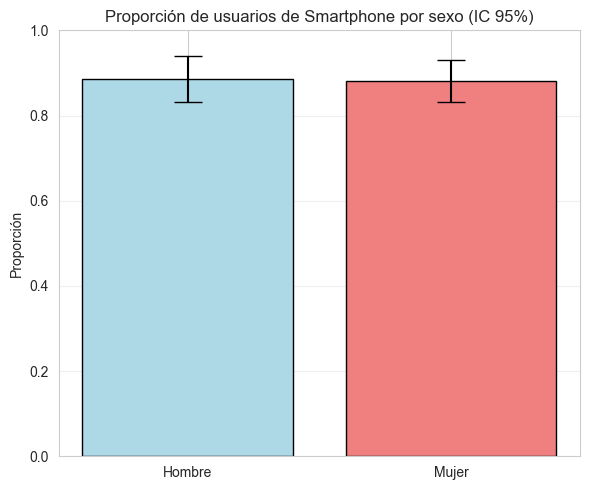

In [4]:
# Calculo la proporción de usuarios de smartphone en cada sexo
p_h = (df_hombres['P8_4_2'] == 1).mean()
p_m = (df_mujeres['P8_4_2'] == 1).mean()
n_h = len(df_hombres)
n_m = len(df_mujeres)

# Realizo la prueba z para diferencia de proporciones
conteos = np.array([(df_hombres['P8_4_2'] == 1).sum(), (df_mujeres['P8_4_2'] == 1).sum()])
tamanos = np.array([n_h, n_m])
z_stat, p_z = proportions_ztest(conteos, tamanos, alternative='two-sided')

# Tamaño del efecto: h de Cohen
h_cohen = 2 * np.arcsin(np.sqrt(p_h)) - 2 * np.arcsin(np.sqrt(p_m))

# Intervalo de confianza del 95% para la diferencia
dif_prop = p_h - p_m
se_p = np.sqrt(p_h * (1 - p_h) / n_h + p_m * (1 - p_m) / n_m)
z_crit = norm.ppf(0.975)
ic_inf_p = dif_prop - z_crit * se_p
ic_sup_p = dif_prop + z_crit * se_p

print("\nPRUEBA Z PARA DIFERENCIA DE PROPORCIONES")
print("-" * 60)
print("Variables analizadas:")
print("• Sexo (hombre / mujer)")
print("• Tipo de celular (Smartphone)")
print("-" * 60)

print(f"Proporción hombres      : {p_h:.3f}")
print(f"Proporción mujeres      : {p_m:.3f}")
print(f"Estadístico z           : {z_stat:.3f}")
print(f"p-valor                 : {p_z:.4f}")
print(f"h de Cohen              : {h_cohen:.3f}")
print(f"Diferencia (H - M)      : {dif_prop:.3f}")
print(f"IC 95% para la diferencia: [{ic_inf_p:.3f}, {ic_sup_p:.3f}]")

print("\nInterpretación:")
if p_z < 0.05:
    print("Se rechaza la hipótesis nula (H₀).")
    print(
        "Existe evidencia estadísticamente significativa de que la proporción "
        "de usuarios de smartphone difiere entre hombres y mujeres."
    )
else:
    print("No se rechaza la hipótesis nula (H₀).")
    print("No se encontró diferencia significativa entre las proporciones.")

# Gráfico de barras con intervalos de confianza
categorias = ['Hombre', 'Mujer']
proporciones = [p_h, p_m]
errores = [z_crit * np.sqrt(p_h*(1-p_h)/n_h), z_crit * np.sqrt(p_m*(1-p_m)/n_m)]

plt.figure(figsize=(6, 5))
plt.bar(categorias, proporciones, color=['lightblue', 'lightcoral'], edgecolor='black')
plt.errorbar(categorias, proporciones, yerr=errores, fmt='none', capsize=10, color='black')
plt.title('Proporción de usuarios de Smartphone por sexo (IC 95%)')
plt.ylabel('Proporción')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### **H3: Prueba t de diferencia de medias de EDAD según tipo de celular**

### **Pregunta de investigación complementaria:**
### **¿La edad promedio es diferente entre quienes usan smartphone y quienes usan teléfono básico?**

#### Hipótesis
- H₀: La edad media de los usuarios de smartphone es igual a la de los usuarios de básico (µ_smart = µ_basic).
- H₁: Las medias de edad son diferentes (µ_smart ≠ µ_basic).
- Nivel de significancia: α = 0.05


VERIFICACIÓN DE SUPUESTOS
------------------------------------------------------------
Normalidad Smartphone: W=0.956, p=0.0000
Normalidad Básico:     W=0.959, p=0.2142
Levene:                F=0.322, p=0.5708

PRUEBA t PARA DIFERENCIA DE MEDIAS (EDAD)
------------------------------------------------------------
Variables analizadas:
• Tipo de celular (Smartphone / Básico)
• Edad del usuario
------------------------------------------------------------
Media Smartphone : 34.7 años
Media Básico     : 53.0 años
Estadístico t    : -5.667
Grados de libertad (efectivos): 298.0
p-valor          : 0.0000
d de Cohen       : -1.019
Diferencia de medias : -18.3 años
IC 95% para la diferencia: [-24.3, -12.3]

Interpretación:
Se rechaza la hipótesis nula (H₀).
La edad media de los usuarios de smartphone es significativamente diferente a la de los usuarios de teléfono básico.


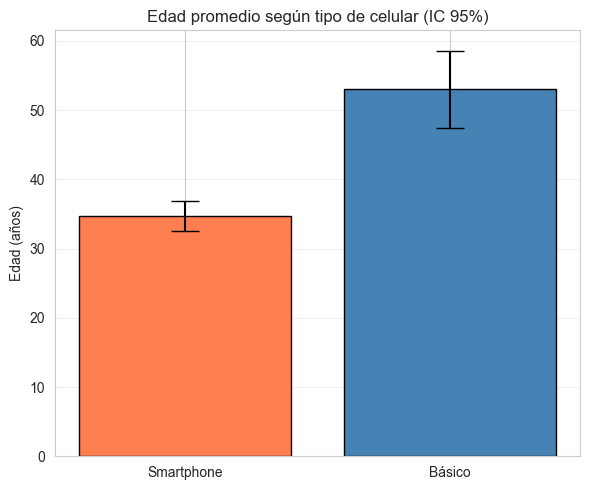

In [5]:
# Separo las edades en dos grupos según el tipo de celular
edad_smart = df_total[df_total['P8_4_2'] == 1]['EDAD']
edad_basic = df_total[df_total['P8_4_2'] == 2]['EDAD']

# Verificación de supuestos: normalidad con Shapiro-Wilk
shap_s = shapiro(edad_smart)
shap_b = shapiro(edad_basic)

# Verificación de homogeneidad de varianzas con Levene
levene_test = levene(edad_smart, edad_basic)

print("\nVERIFICACIÓN DE SUPUESTOS")
print("-" * 60)
print(f"Normalidad Smartphone: W={shap_s.statistic:.3f}, p={shap_s.pvalue:.4f}")
print(f"Normalidad Básico:     W={shap_b.statistic:.3f}, p={shap_b.pvalue:.4f}")
print(f"Levene:                F={levene_test.statistic:.3f}, p={levene_test.pvalue:.4f}")

# Decido si usar t de Student clásica o Welch según la homogeneidad de varianzas
equal_var = levene_test.pvalue >= 0.05
if not equal_var:
    print("→ Varianzas diferentes: se aplica corrección de Welch.")

# Realizo la prueba t para muestras independientes
t_stat, p_t = ttest_ind(edad_smart, edad_basic, equal_var=equal_var)

# Tamaño del efecto: d de Cohen
dif_media = edad_smart.mean() - edad_basic.mean()
var1, var2 = edad_smart.var(), edad_basic.var()
n1, n2 = len(edad_smart), len(edad_basic)
s_pool = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
d_cohen = dif_media / s_pool

# Grados de libertad para el intervalo de confianza (Welch si corresponde)
if not equal_var:
    num = (var1/n1 + var2/n2) ** 2
    denom = ((var1/n1)**2 / (n1-1)) + ((var2/n2)**2 / (n2-1))
    df_t = num / denom
else:
    df_t = n1 + n2 - 2

# Intervalo de confianza del 95% para la diferencia de medias
t_crit = t_dist.ppf(0.975, df_t)
se_dif = np.sqrt(var1/n1 + var2/n2)
ic_media_inf = dif_media - t_crit * se_dif
ic_media_sup = dif_media + t_crit * se_dif

print("\nPRUEBA t PARA DIFERENCIA DE MEDIAS (EDAD)")
print("-" * 60)
print("Variables analizadas:")
print("• Tipo de celular (Smartphone / Básico)")
print("• Edad del usuario")
print("-" * 60)

print(f"Media Smartphone : {edad_smart.mean():.1f} años")
print(f"Media Básico     : {edad_basic.mean():.1f} años")
print(f"Estadístico t    : {t_stat:.3f}")
print(f"Grados de libertad (efectivos): {df_t:.1f}")
print(f"p-valor          : {p_t:.4f}")
print(f"d de Cohen       : {d_cohen:.3f}")
print(f"Diferencia de medias : {dif_media:.1f} años")
print(f"IC 95% para la diferencia: [{ic_media_inf:.1f}, {ic_media_sup:.1f}]")

print("\nInterpretación:")
if p_t < 0.05:
    print("Se rechaza la hipótesis nula (H₀).")
    print(
        "La edad media de los usuarios de smartphone es significativamente "
        "diferente a la de los usuarios de teléfono básico."
    )
else:
    print("No se rechaza la hipótesis nula (H₀).")
    print("No hay evidencia suficiente para afirmar que las medias de edad difieran.")

# Gráfico de barras con intervalos de confianza
medias = [edad_smart.mean(), edad_basic.mean()]
errores_t = [t_crit * np.sqrt(var1/n1), t_crit * np.sqrt(var2/n2)]
grupos = ['Smartphone', 'Básico']

plt.figure(figsize=(6, 5))
plt.bar(grupos, medias, color=['coral', 'steelblue'], edgecolor='black')
plt.errorbar(grupos, medias, yerr=errores_t, fmt='none', capsize=10, color='black')
plt.title('Edad promedio según tipo de celular (IC 95%)')
plt.ylabel('Edad (años)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### **H4: Análisis estratificado por sexo (edad y tipo de celular)**

### **Pregunta de investigación:**
### **¿La asociación entre edad y tipo de celular difiere entre hombres y mujeres?**

#### Hipótesis (exploratoria previa a la regresión logística)
- H₀: La fuerza de asociación entre edad y tipo de celular es la misma en hombres y mujeres.
- H₁: La asociación es diferente (se compara mediante la V de Cramér y posteriormente con un modelo de interacción).
- Nivel de significancia: α = 0.05
- *Nota: La prueba formal de interacción se realizará mediante regresión logística en la sección siguiente.*

In [6]:
# Tabla de contingencia para hombres
tabla_h = pd.crosstab(df_hombres['edad_grupo'], df_hombres['P8_4_2'])
chi2_h, p_h_c, dof_h, _ = chi2_contingency(tabla_h)
v_h = cramer_v(tabla_h)

# Tabla de contingencia para mujeres
tabla_m = pd.crosstab(df_mujeres['edad_grupo'], df_mujeres['P8_4_2'])
chi2_m, p_m_c, dof_m, _ = chi2_contingency(tabla_m)
v_m = cramer_v(tabla_m)

print("\nANÁLISIS ESTRATIFICADO POR SEXO")
print("-" * 60)
print("¿La asociación entre edad y tipo de celular difiere entre hombres y mujeres?")
print("-" * 60)

print(f"Hombres (n={len(df_hombres)}):")
print(f"   χ² = {chi2_h:.3f}, g.l. = {dof_h}, p = {p_h_c:.6f}, V de Cramér = {v_h:.3f}")
print(f"Mujeres (n={len(df_mujeres)}):")
print(f"   χ² = {chi2_m:.3f}, g.l. = {dof_m}, p = {p_m_c:.6f}, V de Cramér = {v_m:.3f}")

print("\nInterpretación:")
# Comparación de la fuerza de asociación
if v_h > v_m:
    print("La V de Cramér es mayor en hombres, lo que sugiere una asociación más fuerte.")
elif v_m > v_h:
    print("La V de Cramér es mayor en mujeres, lo que sugiere una asociación más fuerte.")
else:
    print("La magnitud de la asociación es similar en ambos sexos.")

# Evaluación de significancia por separado
if p_h_c < 0.05 and p_m_c < 0.05:
    print("En ambos sexos la asociación es estadísticamente significativa (α=0.05).")
elif p_h_c < 0.05:
    print("Solo en hombres la asociación alcanza significancia estadística.")
elif p_m_c < 0.05:
    print("Solo en mujeres la asociación alcanza significancia estadística.")
else:
    print("En ninguno de los dos grupos se detecta una asociación significativa.")

print(
    "\nNota: El análisis formal de si la asociación difiere (interacción) "
    "se realizará mediante un modelo de regresión logística con un término "
    "de interacción entre edad y sexo en la siguiente sección."
)


ANÁLISIS ESTRATIFICADO POR SEXO
------------------------------------------------------------
¿La asociación entre edad y tipo de celular difiere entre hombres y mujeres?
------------------------------------------------------------
Hombres (n=131):
   χ² = 22.524, g.l. = 5, p = 0.000416, V de Cramér = 0.415
Mujeres (n=169):
   χ² = 18.120, g.l. = 5, p = 0.002799, V de Cramér = 0.327

Interpretación:
La V de Cramér es mayor en hombres, lo que sugiere una asociación más fuerte.
En ambos sexos la asociación es estadísticamente significativa (α=0.05).

Nota: El análisis formal de si la asociación difiere (interacción) se realizará mediante un modelo de regresión logística con un término de interacción entre edad y sexo en la siguiente sección.
